

## ==============================================================================
## AI-Driven Downlink Optimization in Optical Earth Observation Missions
Master Thesis - Mirko Ponzanelli

Comparative framework: Strategy A (symmetric BCE) with spectral band reduction
Dataset: CloudSEN12+ (7 band selected from literature)
Architecture: U-Net Light
## ==============================================================================


# Google Colab Setup

This notebook is configured to run on Google Colab.
The dataset is downloaded directly from HuggingFace (`csaybar/CloudSEN12-high`)
to the Colab local SSD , no Google Drive needed to minimize I/O overhead.
Disk requirement is ca.70 GB .

In [1]:
# =====================================================================
# Colab: GPU check + dependencies
# =====================================================================
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
!pip install -q huggingface_hub

# =====================================================================
# Download CloudSEN12+ (high quality, L1C bands + labels only)
# =====================================================================
from pathlib import Path
from huggingface_hub import snapshot_download

DATA_DIR = Path("/content/cloudsen12_high")

# Download
print("Ensuring CloudSEN12+ dataset is available (c.a. 70 GB)...")

snapshot_download(
    repo_id="csaybar/CloudSEN12-high",
    repo_type="dataset",
    allow_patterns=["*/L1C_*.dat", "*manual_hq*"],
    local_dir=str(DATA_DIR),
)

print("Dataset ready!")

# Verify
for split in ["train", "val", "test"]:
    path = DATA_DIR / split
    n = len(list(path.glob("*.dat")))
    print(f"{split}: {n} files")

!df -h /content


NVIDIA L4, 23034 MiB
Ensuring CloudSEN12+ dataset is available (c.a. 70 GB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 42 files:   0%|          | 0/42 [00:00<?, ?it/s]

Dataset ready!
train: 14 files
val: 14 files
test: 14 files
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G  109G  127G  47% /


# Google Drive Setup

Mount Google Drive to save all training outputs (models, CSV logs, plots).

In [2]:
# =====================================================================
# Mount Google Drive and define output directory
# =====================================================================
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PROJECT = Path("/content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_7band")
RUN_DIR = DRIVE_PROJECT / "runs_v4"
RUN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results will be saved to: {RUN_DIR}")
!df -h /content/drive

Mounted at /content/drive
Results will be saved to: /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_7band/runs_v4
Filesystem      Size  Used Avail Use% Mounted on
drive           100G  4.8G   96G   5% /content/drive


# 0. Environment Setup

In [3]:

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # only fatal error
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

print(f"TensorFlow: {tf.__version__}")

# configure GPU and enable memory growth to avoid out of memory
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth: ON")
    except Exception as e:
        print("Could not set memory growth:", e)

print(
    "Tensor Flow build:",
    tf.sysconfig.get_build_info().get("cuda_version", "no-cuda-info"),
    tf.sysconfig.get_build_info().get("cudnn_version", "no-cudnn-info"),
)

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth: ON
Tensor Flow build: 12.5.1 9


# 1. Dataset Configuration - 7-Band Physics-Informed Subset

A 7-band subset is selected via consensus analysis over four
 Sentinel-2 ground based cloud detection algorithms. For each band, we
count how many algorithms rely on it; the top-7 by count are retained.

Sources:
s2cloudless: 10 bands (B01,B02,B04,B05,B08,B8A,B09,B10,B11,B12)
ESA L1C QA60/MSK_CLASSI: B01/B02, B04, B10, B11 — [ESA Technical Guide,
Fmask 4.0: B02,B03,B04,B08,B8A,B10,B11,B12
Sen2Cor SCL: all 13 bands — ESA L2A


In [4]:
#====================================
# Configuration
#====================================
DATA_ROOT = Path("/content/cloudsen12_high")

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR   = DATA_ROOT / "val"
TEST_DIR  = DATA_ROOT / "test"

# dataset parameters
NUM_S2_BANDS_FULL = 13   # Total Sentinel-2 bands in CloudSEN12+
# 7-band subset: indices into the 13-band stack
BAND_INDICES = [1, 3, 7, 8, 10, 11, 12]
BAND_NAMES = ['B02','B04','B08','B8A','B10','B11','B12']
NUM_S2_BANDS = len(BAND_INDICES)  # 7 bands for cloud detection
IGNORE_LABEL = 99        # no-data label in CloudSEN12
TARGET_SIZE = 512        # Patch size (H, W)
ORIGINAL_SIZE = 509       # Original CloudSEN12+ p509 patch size
BATCH_SIZE = 16           # Batch size (bigger in colab)
DIVISOR = 10000.0        # Sentinel-2 L1C reflectance scaling factor

# Label mapping: CloudSEN12 classes to binary
# 0: Clear is 0 (transmit)
# 1: Thick cloud is 1 (discard)
# 2: Thin cloud is 1 (discard)
# 3: Cloud shadow is 0 (transmit , they have still information )
CLOUD_CLASSES = {1, 2}   # classes mapped to "cloud" (positive class)
# Split sizes (CloudSEN12+ high quality, p509 padded to 512)
SPLIT_SIZES = {"train": 8490, "val": 535, "test": 975}

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"RUN_DIR:    {RUN_DIR}")
for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(f"  {d.name}: exists={d.exists()}")

DATA_ROOT: /content/cloudsen12_high
RUN_DIR:    /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_7band/runs_v4
  train: exists=True
  val: exists=True
  test: exists=True


# 2. Data Pipeline

Memmap-based pipeline reading from HuggingFace CloudSEN12-high.
Each band is a separate `.dat` file; images are already 512×512.
Zero-padded border pixels (509->512) are detected and marked as
`IGNORE_LABEL = 99` to exclude them from loss and metrics.


In [5]:
# =====================================================================
# Memmap-based data pipeline - 7 band loading
# =====================================================================
# Only the 7 selected bands are loaded from disk via BAND_INDICES.
# =====================================================================

L1C_BAND_FILES = [
    "L1C_B1.dat", "L1C_B2.dat", "L1C_B3.dat", "L1C_B4.dat",
    "L1C_B5.dat", "L1C_B6.dat", "L1C_B7.dat", "L1C_B8.dat",
    "L1C_B8A.dat", "L1C_B9.dat", "L1C_B10.dat", "L1C_B11.dat",
    "L1C_B12.dat",
]


def load_memmap_split(split_dir):
    """Open memmap arrays for selected bands + label."""
    split_name = Path(split_dir).name
    n = SPLIT_SIZES[split_name]
    shape = (n, TARGET_SIZE, TARGET_SIZE)

    # Load only the 7 selected bands
    bands = []
    for idx in BAND_INDICES:
        fpath = Path(split_dir) / L1C_BAND_FILES[idx]
        bands.append(np.memmap(str(fpath), dtype="int16", mode="r", shape=shape))

    label = np.memmap(
        str(Path(split_dir) / "LABEL_manual_hq.dat"), dtype="int8", mode="r", shape=shape
    )
    return bands, label, n


def make_dataset(split_dir, batch_size=BATCH_SIZE, shuffle=True, augment=False):
    """Create a tf.data.Dataset from memmap arrays.

    Only the 7 cloud-relevant bands are loaded and stacked.
    Zero-padded pixels (all selected bands == 0) are marked IGNORE_LABEL
    so they are excluded from loss and all metrics.

    Output:
      x : float32 (512, 512, 7)  normalized reflectance [0, 1]
      y : float32 (512, 512, 1)  binary mask {0, 1, 99}
    """
    bands, label, n_samples = load_memmap_split(split_dir)
    split_name = Path(split_dir).name
    print(f"  {split_name}: {n_samples} samples ({len(bands)} bands: {BAND_NAMES})")

    def generator():
        indices = list(range(n_samples))
        if shuffle:
            np.random.shuffle(indices)

        for i in indices:

            # stack the 7 selected bands into (H, W, 7)
            band_patches = [band[i] for band in bands]
            # stack bands into a multispectral image (H, W, 13)
            x = np.stack(band_patches, axis=-1)
            # convert to float32
            x = x.astype(np.float32)
            #  normalize reflectance
            x = x / DIVISOR
            # values between 0 and 1
            x = np.clip(x, 0.0, 1.0)

            # binary label mapping
            y = label[i].astype(np.float32)
            # convert labels to integer class codes
            y_int = y.astype(int)
            # identify pixels belonging to cloud classes
            is_cloud = np.isin(y_int, list(CLOUD_CLASSES))

            # map cloud pixels to 1.0 and all others to 0.0
            y_bin = np.where(is_cloud, 1.0, 0.0)
            y_bin = np.where(y_int == IGNORE_LABEL, float(IGNORE_LABEL), y_bin)

            # padding: if all 7 selected bands are zero, mark as ignore
            all_zero = np.all(x == 0.0, axis=-1)

            # restore ignore pixels
            y_bin = np.where(all_zero, float(IGNORE_LABEL), y_bin)

            yield x, y_bin[..., np.newaxis]

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(TARGET_SIZE, TARGET_SIZE, NUM_S2_BANDS), dtype=tf.float32),
            tf.TensorSpec(shape=(TARGET_SIZE, TARGET_SIZE, 1), dtype=tf.float32),
        ),
    )

    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size, drop_remainder=True)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


@tf.function
def _augment(x, y):
    """Random augmentation: flips, 90° rotations, additive Gaussian noise."""
   # random horizontal flip
    if tf.random.uniform(()) > 0.5:
        x = tf.image.flip_left_right(x)
        y = tf.image.flip_left_right(y)
    # random vertical flip
    if tf.random.uniform(()) > 0.5:
        x = tf.image.flip_up_down(x)
        y = tf.image.flip_up_down(y)
    k = tf.random.uniform((), maxval=4, dtype=tf.int32)
    # random 90° rotation
    x = tf.image.rot90(x, k)
    y = tf.image.rot90(y, k)
    # additive gaussian noise
    x = x + tf.random.normal(tf.shape(x), mean=0.0, stddev=0.01)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y


In [6]:
print("Building datasets...")
train_ds = make_dataset(TRAIN_DIR, shuffle=True, augment=True)
val_ds   = make_dataset(VAL_DIR,   shuffle=False, augment=False)
test_ds  = make_dataset(TEST_DIR,  shuffle=False, augment=False)

# check
x_sample, y_sample = next(iter(val_ds))
print(f"\nBatch shapes: x={x_sample.shape}, y={y_sample.shape}")
print(f"x range: [{x_sample.numpy().min():.3f}, {x_sample.numpy().max():.3f}]")
print(f"y unique: {np.unique(y_sample.numpy())}")

Building datasets...
  train: 8490 samples (7 bands: ['B02', 'B04', 'B08', 'B8A', 'B10', 'B11', 'B12'])
  val: 535 samples (7 bands: ['B02', 'B04', 'B08', 'B8A', 'B10', 'B11', 'B12'])
  test: 975 samples (7 bands: ['B02', 'B04', 'B08', 'B8A', 'B10', 'B11', 'B12'])

Batch shapes: x=(16, 512, 512, 7), y=(16, 512, 512, 1)
x range: [0.000, 1.000]
y unique: [ 0.  1. 99.]


## 2.1 Dataset Statistics & Visualization

--- Train Statistics ---
Images: 8480
Cloud Fraction (Mean): 0.369
No-Data (99) Fraction (Mean): 0.012
-------------------------
--- Val Statistics ---
Images: 528
Cloud Fraction (Mean): 0.381
No-Data (99) Fraction (Mean): 0.012
-------------------------
--- Test Statistics ---
Images: 960
Cloud Fraction (Mean): 0.385
No-Data (99) Fraction (Mean): 0.012
-------------------------


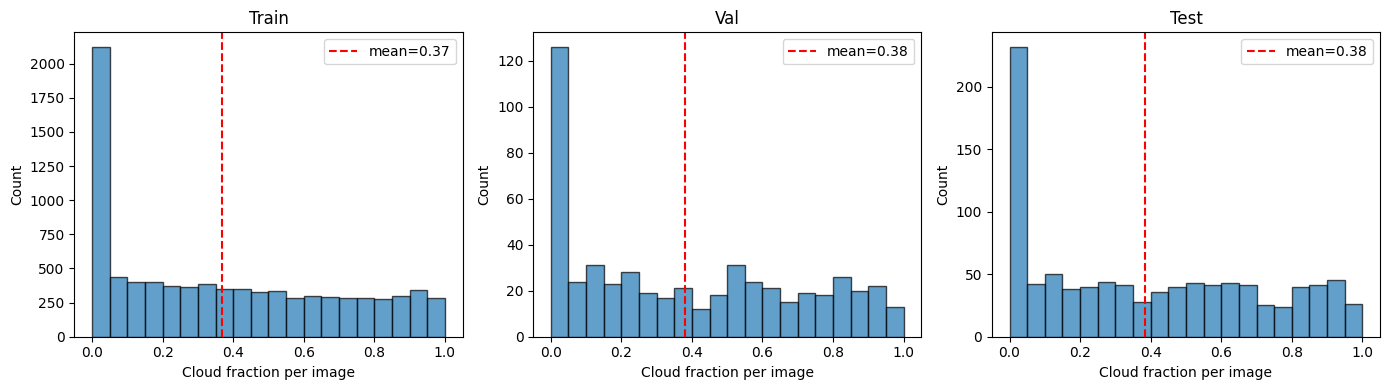

In [7]:
def compute_split_stats(ds, name="split"):
    """Compute cloud fraction statistics for a dataset split."""
    # empty list to store cloud fractions
    cloud_fracs = []
    ignore_fracs = []
    #loop through each batch in the dataset
    for xb, yb in ds:
         #convert label in numpy array
        yb = yb.numpy()

        # process each image
        for i in range(yb.shape[0]):
            #get the mask
            mask = yb[i]
            # total pixels
            total_pixels = mask.size

            # count of No Data pixels i.e. equal to99
            num_ignore = np.sum(mask == IGNORE_LABEL)
            ignore_fracs.append(num_ignore / total_pixels)

            #remove pixels with IGNORE_LABEL
            valid = mask[mask != IGNORE_LABEL]
            # process if there are valid pixels
            if valid.size > 0:
                 # 1 = cloud, 0 = clear i.e. fraction of clouds
                cloud_fraction = float(np.mean(valid))
                cloud_fracs.append(cloud_fraction)

    cloud_fracs = np.array(cloud_fracs)
    ignore_fracs = np.array(ignore_fracs)

    # print statistics
    print(f"--- {name} Statistics ---")
    print(f"Images: {len(cloud_fracs)}")
    print(f"Cloud Fraction (Mean): {cloud_fracs.mean():.3f}")
    print(f"No-Data (99) Fraction (Mean): {ignore_fracs.mean():.3f}")
    print("-" * 25)

    return cloud_fracs, ignore_fracs

# compute statistics for every split
cf_train, ign_train = compute_split_stats(train_ds, "Train")
cf_val, ign_val     = compute_split_stats(val_ds, "Val")
cf_test, ign_test   = compute_split_stats(test_ds, "Test")

# subplot for each split
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# histogram for each dataset split
splits = [cf_train, cf_val, cf_test]
names = ["Train", "Val", "Test"]

for ax, cf, name in zip(axes, splits, names):
    # plot histogram with 20 bins
    ax.hist(cf, bins=20, edgecolor="k", alpha=0.7)

    #  vertical line for the mean
    mean_value = cf.mean()
    ax.axvline(mean_value, color="r", ls="--", label=f"mean={mean_value:.2f}")

    # labels and title
    ax.set_xlabel("Cloud fraction per image")
    ax.set_ylabel("Count")
    ax.set_title(name)
    ax.legend()

# space between plots
plt.tight_layout()

# save and display
plt.savefig("cloud_fraction_distribution.png", dpi=150)
plt.show()

# 3. Model Architecture - U-Net Light

Identical architecture to the 13-band baseline. The only difference is
`input_shape=(512, 512, 7)`: the first Conv2D accepts 7 channels.


In [8]:
def conv_block(x, filters, dropout_rate=0.2):
    """Two Conv2D + Batch Normalization + ReLU layers with optional dropout."""
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    return x


def build_unet_light(input_shape=(512, 512, 7), filters=(32, 64, 128)):
    """U-Net-light for binary cloud detection.

    Parameters
    ----------
    input_shape : tuple
        (H, W, C)  7 selected Sentinel-2 band
        [B02, B03, B04, B08, B8A, B10, B11].
    filters : tuple
        Number of filters per encoder level.

    Returns
    -------
    tf.keras.Model with sigmoid output (H, W, 1).
    """
    inp = tf.keras.Input(shape=input_shape, name="sentinel2_input")

    #  Encoder
    skips = []
    x = inp
    for f in filters:
        x = conv_block(x, f)
        skips.append(x)
        x = tf.keras.layers.MaxPooling2D(2)(x)

    # Bottleneck
    x = conv_block(x, filters[-1] * 2)

    # Decoder
    for f, skip in zip(reversed(filters), reversed(skips)):
        x = tf.keras.layers.UpSampling2D(2, interpolation="bilinear")(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        x = conv_block(x, f)

    # output
    x = tf.keras.layers.Conv2D(1, 1, padding="same", name="logits")(x)
    out = tf.keras.layers.Activation("sigmoid", dtype="float32", name="cloud_prob")(x)

    model = tf.keras.Model(inp, out, name="UNet_light_binary")
    return model

In [9]:
model = build_unet_light(
    input_shape=(TARGET_SIZE, TARGET_SIZE, NUM_S2_BANDS),
    filters=(32, 64, 128),
)

model.summary()

total_params = model.count_params()
print(f"\n{'='*70}")
print(f"Total parameters:     {total_params:>12,}")
print(f"Model size (FP32):    {total_params * 4 / 1e6:>12.2f} MB")
print(f"{'='*70}")

Model: "UNet_light_binary"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sentinel2_input     │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      2,016 │ sentinel2_input[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512, 512,  │          0 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      9,216 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 256,  │          0 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │     36,864 │ dropout_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ re_lu_3[0][0]   

 Total params: 1,952,257 (7.45 MB)

 Trainable params: 1,949,441 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)


Total parameters:        1,952,257
Model size (FP32):            7.81 MB


# 4. Loss Functions and Metrics

**Strategy A only (symmetric BCE).** The 7-band experiment isolates the
effect of band reduction against the 13-band baseline. 

The asymmetric strategies (B, C, D) are not repeated here.


In [10]:
# =====================================================================
# Masked Binary Cross-Entropy — symmetric (Strategy A, C)
# =====================================================================
@tf.function
def masked_bce_symmetric(y_true, y_pred):
    """Standard BCE with masking for ignore label.

    y_true: (B, H, W, 1) float32, values in {0, 1, IGNORE_LABEL}
    y_pred: (B, H, W, 1) float32, sigmoid probabilities
    """
    # cast inputs to float32 for calculation
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # create a mask: 1 for valid pixels, 0 for IGNORE_LABEL
    mask = tf.not_equal(y_true, float(IGNORE_LABEL))
    mask_f = tf.cast(mask, tf.float32)

    # replace IGNORE_LABEL with 0 to avoid NaN in BCE
    y_safe = tf.where(mask, y_true, tf.zeros_like(y_true))

    # compute BCE (shape: B,H,W)
    bce = tf.keras.losses.binary_crossentropy(y_safe, y_pred)
    # zero out ignored pixels
    bce = bce * mask_f[:, :, :, 0]

    # return mean loss over valid pixels only
    return tf.reduce_sum(bce) / (tf.reduce_sum(mask_f) )


# =====================================================================
# Masked metrics
# =====================================================================
@tf.function
def masked_binary_accuracy(y_true, y_pred):
    """Pixel-level accuracy ignoring IGNORE_LABEL."""
    # cast inputs to float32 for calculation
    y_true = tf.cast(y_true, tf.float32)
    # create a mask: 1 for valid pixels, 0 for IGNORE_LABEL
    mask = tf.not_equal(y_true, float(IGNORE_LABEL))
    # probability in class
    pred_class = tf.cast(y_pred >= 0.5, tf.float32)
    # check correctness
    correct = tf.logical_and(mask, tf.equal(y_true, pred_class))

    # return accuracy over valid pixels only
    return tf.reduce_sum(tf.cast(correct, tf.float32)) / (
        tf.reduce_sum(tf.cast(mask, tf.float32))
    )


@tf.function
def masked_cloud_iou(y_true, y_pred):
    """IoU (Intersection Over Union)  for cloud class (positive class = 1), ignoring IGNORE_LABEL."""
    # cast inputs to float32 for calculation and remove channel
    y_true = tf.cast(y_true[:, :, :, 0], tf.float32)
    y_pred_cls = tf.cast(y_pred[:, :, :, 0] >= 0.5, tf.float32)

    # create a mask: 1 for valid pixels, 0 for IGNORE_LABEL
    mask = tf.not_equal(y_true, float(IGNORE_LABEL))
    mask_f = tf.cast(mask, tf.float32)
    # GT and prediction w/o ignored pixels
    gt = y_true * mask_f
    pr = y_pred_cls * mask_f
    # intersection
    inter = tf.reduce_sum(gt * pr)
    #union
    union = tf.reduce_sum(gt) + tf.reduce_sum(pr) - inter
    return inter / (union + 1e-8)

# 5. Experiment Registry & Training

All experiments are defined in a central registry.
Each run uses identical architecture, seed, dataset, and callbacks.
The only controlled variables are the loss function and, where
noted, the learning rate.

In [11]:
# =====================================================================
# Experiment Registry - Strategy A only (7 band)
# =====================================================================

EXPERIMENT_REGISTRY = {
    "A": ("sym_bce", "A (Symmetric, 7 band)", masked_bce_symmetric, 1e-3, 8),
}

ALL_TAGS = ["A"]

MODEL_PATHS = {
    tag: str(RUN_DIR / info[0] / "best.keras")
    for tag, info in EXPERIMENT_REGISTRY.items()
}

print("Experiment Registry:")
print(f"{'Tag':<6} | {'Dir':<14} | {'Display':<28} | {'LR':>6} | {'Pat':>3}")
print("-" * 65)
for tag in ALL_TAGS:
    d, name, _, lr, pat = EXPERIMENT_REGISTRY[tag]
    print(f"{tag:<6} | {d:<14} | {name:<28} | {lr:6.0e} | {pat:3d}")
print(f"\nInput bands: {NUM_S2_BANDS} ({BAND_NAMES})")


Experiment Registry:
Tag    | Dir            | Display                      |     LR | Pat
-----------------------------------------------------------------
A      | sym_bce        | A (Symmetric, 7 band)        |  1e-03 |   8

Input bands: 7 (['B02', 'B04', 'B08', 'B8A', 'B10', 'B11', 'B12'])


In [12]:
# =====================================================================
# Training infrastructure
# =====================================================================

def get_callbacks(run_dir_name, patience=8):
    """Standard callbacks saves to Google Drive (RUN_DIR)."""
    out_dir = RUN_DIR / run_dir_name
    out_dir.mkdir(parents=True, exist_ok=True)

    return [
        tf.keras.callbacks.ModelCheckpoint(
            str(out_dir / "best.keras"),
            monitor="val_masked_cloud_iou",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_masked_cloud_iou",
            mode="max",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(str(out_dir / "history.csv")),
    ], out_dir


def train_experiment(tag, epochs=100):
    """Train a single experiment from the registry.

    Skips training if best.keras already exists on Drive.
    """
    run_dir_name, display_name, loss_fn, lr, patience = EXPERIMENT_REGISTRY[tag]
    best_path = RUN_DIR / run_dir_name / "best.keras"

    if best_path.exists():
        print(f"\n  SKIP {tag} ({display_name})  already trained at {best_path}")
        return None, None

    print(f"\n{'='*70}")
    print(f"  TRAINING: {tag} — {display_name}")
    print(f"  Loss: {loss_fn.name}  |  LR: {lr}  |  Patience: {patience}")
    print(f"  Output: {RUN_DIR / run_dir_name}")
    print(f"{'='*70}\n")

    tf.random.set_seed(42)
    np.random.seed(42)

    mdl = build_unet_light(
        input_shape=(TARGET_SIZE, TARGET_SIZE, NUM_S2_BANDS),
        filters=(32, 64, 128),
    )

    mdl.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=[masked_binary_accuracy, masked_cloud_iou],
    )

    callbacks, out_dir = get_callbacks(run_dir_name, patience=patience)

    history = mdl.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )

    mdl.save(str(out_dir / "final.keras"))
    print(f"  Model saved to {out_dir}")

    return mdl, history


## 5.1 Run All Training Experiments

Training iterates over the experiment registry.
If a `best.keras` file already exists on Drive (from a previous run),
training is skipped  (safe for runtime reconnection).

In [13]:
# =====================================================================
# Train all experiments
# =====================================================================
trained_models = {}
trained_histories = {}

for tag in ALL_TAGS:
    mdl, hist = train_experiment(tag, epochs=50)
    if mdl is not None:
        trained_models[tag] = mdl
        trained_histories[tag] = hist

print(f"\nTraining complete. {len(trained_models)} new models trained.")


  TRAINING: A — A (Symmetric, 7 band)
  Loss: masked_bce_symmetric  |  LR: 0.001  |  Patience: 8
  Output: /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_7band/runs_v4/sym_bce

Epoch 1/50
    530/Unknown 546s 881ms/step - loss: 0.4017 - masked_binary_accuracy: 0.8284 - masked_cloud_iou: 0.6113

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_masked_cloud_iou improved from None to 0.65176, saving model to /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_7band/runs_v4/sym_bce/best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_7band/runs_v4/sym_bce/best.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 561s 910ms/step - loss: 0.3669 - masked_binary_accuracy: 0.8462 - masked_cloud_iou: 0.6409 - val_loss: 0.4166 - val_masked_binary_accuracy: 0.8122 - val_masked_cloud_iou: 0.6518 - learning_rate: 0.0010
Epoch 2/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - loss: 0.3353 - masked_binary_accuracy: 0.8604 - masked_cloud_iou: 0.6730
Epoch 2: val_masked_cloud_iou did not improve from 0.65176
530/530 ━━━━━━━━━━━━━━━━━━━━ 477s 898ms/step - loss: 0.3265 - masked_binary_accuracy: 0.8639 - masked_cloud_iou: 0.6766 - val_loss: 0.3465 - val_masked_binary_accuracy: 0.8567 - val_masked_cloud_iou: 0.6436 - learning_rate: 0.0010
Epoch 3/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - loss: 0.3019 - ma

## 5.2 Learning Curves

Loaded from CSV files on Google Drive .

  A: 42 epochs from CSV


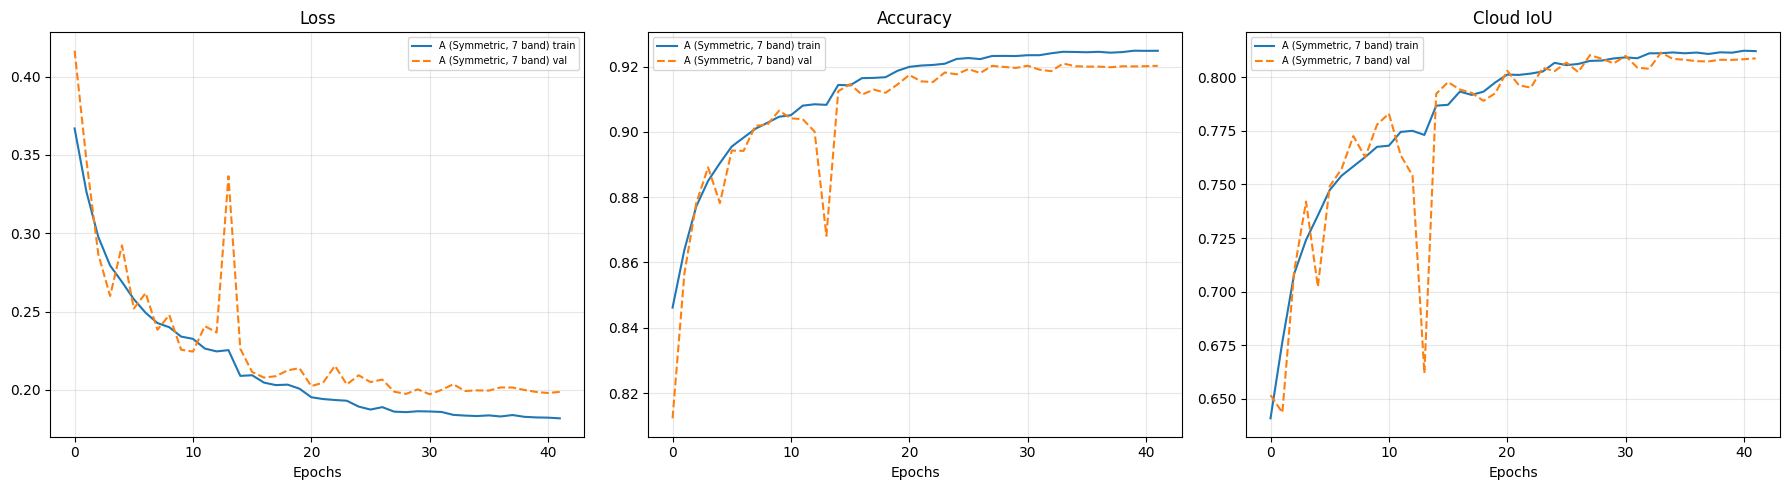

In [14]:
import pandas as pd

def load_history(tag):
    """Load training history from CSV on Drive."""
    run_dir_name = EXPERIMENT_REGISTRY[tag][0]
    csv_path = RUN_DIR / run_dir_name / "history.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f"  {tag}: {len(df)} epochs from CSV")
        return df.to_dict(orient='list')
    print(f"  {tag}: WARNING — no CSV found")
    return None


def plot_learning_curves(tags, save_name="learning_curves.png"):
    """Plot learning curves for given experiment tags."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for tag in tags:
        hd = load_history(tag)
        if hd is None:
            continue
        name = EXPERIMENT_REGISTRY[tag][1]
        axes[0].plot(hd["loss"], label=f"{name} train")
        axes[0].plot(hd["val_loss"], "--", label=f"{name} val")
        axes[1].plot(hd["masked_binary_accuracy"], label=f"{name} train")
        axes[1].plot(hd["val_masked_binary_accuracy"], "--", label=f"{name} val")
        axes[2].plot(hd["masked_cloud_iou"], label=f"{name} train")
        axes[2].plot(hd["val_masked_cloud_iou"], "--", label=f"{name} val")

    axes[0].set_title("Loss")
    axes[1].set_title("Accuracy")
    axes[2].set_title("Cloud IoU")

    for ax in axes:
        ax.set_xlabel("Epochs")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(RUN_DIR / save_name), dpi=150)
    plt.show()


# Plot all
plot_learning_curves(ALL_TAGS)


# 6. Pixel-Level Evaluation — Standard Validation Pipeline

Standard field metrics alongside operational metrics as required
by cloud detection and semantic segmentation literature.

**Standard metrics:** Overall Accuracy (OA), Cloud IoU, Clear IoU,
Mean IoU (mIoU), Cohen's Kappa .

**Operational metrics:** FPR, FNR, Precision, Recall, F1..



In [15]:
# =====================================================================
# Pixel-level evaluation — confusion matrix counts + standard metrics
# =====================================================================

def _cohens_kappa(TP, FP, TN, FN):
    """Cohen's Kappa from confusion matrix counts."""
    N = TP + FP + TN + FN
    if N == 0:
        return 0.0
    po = (TP + TN) / N                                        # observed agreement
    pe = ((TP+FP)*(TP+FN) + (TN+FN)*(TN+FP)) / (N * N)       # expected (chance)
    return (po - pe) / (1 - pe) if pe != 1.0 else 1.0


def evaluate_pixel_level(model, ds, t_pix=0.5):
    """Count TP, FP, TN, FN on all valid pixels.

    Returns raw counts, standard field metrics (OA, mIoU, Kappa),
    and operational metrics (FPR, FNR, Precision, Recall, F1).
    """
    TP = FP = TN = FN = 0
    for xb, yb in ds:
        yb   = tf.cast(yb, tf.float32)
        prob = model(xb, training=False)
        mask = tf.not_equal(yb, float(IGNORE_LABEL))
        pred = tf.cast(prob >= t_pix, tf.float32)
        m    = tf.cast(mask, tf.float32)
        y_valid = yb * m
        p_valid = pred * m

        TP += float(tf.reduce_sum(y_valid * p_valid))
        FP += float(tf.reduce_sum((1 - y_valid) * p_valid * m))
        TN += float(tf.reduce_sum((1 - y_valid) * (1 - p_valid) * m))
        FN += float(tf.reduce_sum(y_valid * (1 - p_valid) * m))

    eps = 1e-8
    cloud_iou = TP / (TP + FP + FN + eps)
    clear_iou = TN / (TN + FP + FN + eps)

    return {
        # Raw confusion matrix counts
        "TP": int(TP), "FP": int(FP), "TN": int(TN), "FN": int(FN),
        # Standard field metrics
        "OA":        (TP + TN) / (TP + FP + TN + FN + eps),
        "Cloud_IoU": cloud_iou,
        "Clear_IoU": clear_iou,
        "mIoU":      0.5 * (cloud_iou + clear_iou),
        "Kappa":     _cohens_kappa(TP, FP, TN, FN),
        # Operational metrics
        "Precision": TP / (TP + FP + eps),
        "Recall":    TP / (TP + FN + eps),
        "F1":        2*TP / (2*TP + FP + FN + eps),
        "FPR":       FP / (FP + TN + eps),
        "FNR":       FN / (FN + TP + eps),
    }


In [16]:
# =====================================================================
# Standard report: confusion matrix heatmaps and comparative table
# =====================================================================

def plot_confusion_matrices(all_metrics, tags, save_name="confusion_matrices.png"):
    """Plot confusion matrix heatmaps for all models."""
    n = len(tags)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4), squeeze=False)
    # if there is only one subplot, axes will be a 2D array, so we flatten it
    axes = axes.flatten()

    for ax, tag in zip(axes, tags):
        m = all_metrics[tag]
        name = EXPERIMENT_REGISTRY[tag][1]
        cm = np.array([[m['TN'], m['FP']],
                       [m['FN'], m['TP']]])
        cm_pct = cm / cm.sum() * 100

        ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=cm_pct.max())
        for ii in range(2):
            for jj in range(2):
                ax.text(jj, ii, f"{cm[ii,jj]:,.0f}\n({cm_pct[ii,jj]:.1f}%)",
                        ha='center', va='center', fontsize=9,
                        color='white' if cm_pct[ii,jj] > cm_pct.max()/2 else 'black')

        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['Clear', 'Cloud'])
        ax.set_yticklabels(['Clear', 'Cloud'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')
        ax.set_title(f"{name}\nmIoU={m['mIoU']:.3f}  k={m['Kappa']:.3f}", fontsize=9)

    plt.tight_layout()
    plt.savefig(str(RUN_DIR / save_name), dpi=150, bbox_inches='tight')
    plt.show()


def summary_table(all_metrics, tags):
    """Print comparative table: standard + operational metrics."""
    print(f"\n{'Model':<20} | {'OA':>6} | {'mIoU':>6} | {'Kappa':>6} | "
          f"{'Prec':>6} | {'Rec':>6} | {'F1':>6} | {'FPR':>6}")
    print('-' * 90)
    for tag in tags:
        m = all_metrics[tag]
        name = EXPERIMENT_REGISTRY[tag][1]
        print(f"{name:<20} | {m['OA']:6.4f} | {m['mIoU']:6.4f} | {m['Kappa']:6.4f} | "
              f"{m['Precision']:6.4f} | {m['Recall']:6.4f} | {m['F1']:6.4f} | {m['FPR']:6.4f}")

  STANDARD VALIDATION — TEST SET (t_pix = 0.5)

--- A : A (Symmetric, 7 band) ---
  Confusion Matrix:
                  Pred Clear    Pred Cloud
    GT Clear     144,969,265     8,084,264
    GT Cloud      11,833,491    83,830,740
  OA=0.9199  mIoU=0.8436  Kappa=0.8296
  Prec=0.9120  Rec=0.8763  F1=0.8938  FPR=0.0528


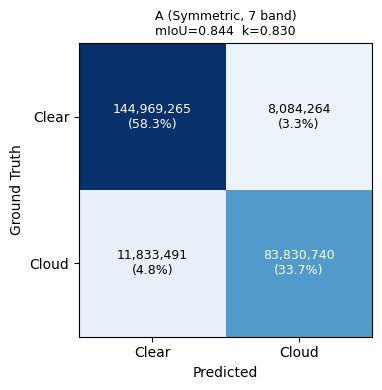

In [17]:
# =====================================================================
# Run standard evaluation on TEST set - all models
# =====================================================================
import gc

def load_model(tag):
    return tf.keras.models.load_model(MODEL_PATHS[tag], compile=False)

def release_model(model):
    del model
    gc.collect()


print('=' * 60)
print('  STANDARD VALIDATION — TEST SET (t_pix = 0.5)')
print('=' * 60)

all_test_metrics = {}
for tag in ALL_TAGS:
    mdl = load_model(tag)
    m = evaluate_pixel_level(mdl, test_ds, t_pix=0.5)
    all_test_metrics[tag] = m
    name = EXPERIMENT_REGISTRY[tag][1]

    # Print per model report
    print(f"\n--- {tag} : {name} ---")
    print(f"  Confusion Matrix:")
    print(f"                  Pred Clear    Pred Cloud")
    print(f"    GT Clear    {m['TN']:>12,}  {m['FP']:>12,}")
    print(f"    GT Cloud    {m['FN']:>12,}  {m['TP']:>12,}")
    print(f"  OA={m['OA']:.4f}  mIoU={m['mIoU']:.4f}  Kappa={m['Kappa']:.4f}")
    print(f"  Prec={m['Precision']:.4f}  Rec={m['Recall']:.4f}  F1={m['F1']:.4f}  FPR={m['FPR']:.4f}")
    release_model(mdl)

# confusion matrix
plot_confusion_matrices(all_test_metrics, ALL_TAGS)


# 7. Tile-Level Evaluation

At tile level each image is classified as cloudy (discard) or
clear (transmit) based on the predicted cloud fraction.
If the fraction of cloud pixels ≥ `t_img` (70 % is consistent with ClouScout) the tile is discarded.

In [18]:
def evaluate_tile_level(model, ds, t_pix=0.5, t_img=0.70):
    """Classify each image as transmit/discard and count errors."""
    TP = FP = TN = FN = 0

    for xb, yb in ds:
        # cloud probability and convert to numpy
        prob = model(xb, training=False).numpy()
        # ground truth to numpy
        yb   = yb.numpy()
        # loop over images
        for i in range(prob.shape[0]):
            # image cloud probability
            p = prob[i, :, :, 0]
            # image ground truth
            y = yb[i, :, :, 0]
            # valid mask bolean
            valid = (y != IGNORE_LABEL)
            # predicted cloud fraction
            pred_cf = (p[valid] >= t_pix).mean()
            # ground truth cloud fraction
            gt_cf   = y[valid].mean()

            # prediction tile
            pred_tile = int(pred_cf >= t_img)
            # ground truth tile
            gt_tile   = int(gt_cf   >= t_img)

            if   gt_tile == 1 and pred_tile == 1: TP += 1
            elif gt_tile == 0 and pred_tile == 1: FP += 1
            elif gt_tile == 1 and pred_tile == 0: FN += 1
            else:                                 TN += 1

    eps = 1e-8
    fpr = FP / (FP + TN + eps)
    fnr = FN / (FN + TP + eps)
    de  = TP / (TP + FN + eps)        # downlink efficiency i.e. recall

    return {
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "FPR": fpr, "FNR": fnr, "Downlink_Efficiency": de,

    }


In [19]:
# =====================================================================
# Tile-level evaluation on the test set
# =====================================================================
print("Tile-level evaluation on TEST set (t_pix=0.5, t_img=0.70)\n")
print(f"{'Tag':<6} | {'Name':<20} | {'Tile FPR':>9} | {'Tile FNR':>9} | {'DL Eff':>9}")
print('-' * 70)

tile_default = {}
for tag in ALL_TAGS:
    mdl = load_model(tag)
    t = evaluate_tile_level(mdl, test_ds)
    tile_default[tag] = t
    name = EXPERIMENT_REGISTRY[tag][1]
    print(f"{tag:<6} | {name:<20} | {t['FPR']:9.4f} | {t['FNR']:9.4f} | {t['Downlink_Efficiency']:9.4f}")
    release_model(mdl)


Tile-level evaluation on TEST set (t_pix=0.5, t_img=0.70)

Tag    | Name                 |  Tile FPR |  Tile FNR |    DL Eff
----------------------------------------------------------------------
A      | A (Symmetric, 7 band) |    0.0422 |    0.1393 |    0.8607


## 8.  Threshold Sweep (Streaming)


In [20]:
# =====================================================================
# Streaming sweep
# =====================================================================


THRESHOLDS = np.concatenate([
    [0.001, 0.005, 0.01, 0.02],           # near-zero
    np.arange(0.05, 0.96, 0.025),          # core range
    [0.96, 0.98, 0.99, 0.995, 0.999],      # near-one
])
T_IMG = 0.70       # fixed tile-level threshold
FPR_LIMIT = 0.05   # operational constraint
N_THR = len(THRESHOLDS)


def streaming_sweep(model, ds):
    """Run model on a dataset and compute pixel + tile metrics for every
    threshold in a single pass. No predictions are stored."""
    pix_TP = np.zeros(N_THR)
    pix_FP = np.zeros(N_THR)
    pix_TN = np.zeros(N_THR)
    pix_FN = np.zeros(N_THR)

    tile_TP = np.zeros(N_THR)
    tile_FP = np.zeros(N_THR)
    tile_TN = np.zeros(N_THR)
    tile_FN = np.zeros(N_THR)

    n_images = 0
    for xb, yb in ds:
        yb = yb.numpy()
        for i in range(xb.shape[0]):
            prob = model(xb[i:i+1], training=False).numpy()
            y = yb[i, :, :, 0]
            p = prob[0, :, :, 0]

            valid = (y != IGNORE_LABEL)
            y_v = y[valid]
            p_v = p[valid]

            gt_cf = y_v.mean()
            gt_tile = int(gt_cf >= T_IMG)

            p_row = p_v[np.newaxis, :]
            t_col = THRESHOLDS[:, np.newaxis]
            pred_mask = (p_row >= t_col)

            gt_cloud = (y_v == 1)
            gt_clear = (y_v == 0)

            pix_TP += np.sum(pred_mask & gt_cloud, axis=1)
            pix_FP += np.sum(pred_mask & gt_clear, axis=1)
            pix_FN += np.sum(~pred_mask & gt_cloud, axis=1)
            pix_TN += np.sum(~pred_mask & gt_clear, axis=1)

            pred_cfs = pred_mask.mean(axis=1)
            pred_tiles = (pred_cfs >= T_IMG).astype(int)

            for j in range(N_THR):
                pt = pred_tiles[j]
                if   gt_tile == 1 and pt == 1: tile_TP[j] += 1
                elif gt_tile == 0 and pt == 1: tile_FP[j] += 1
                elif gt_tile == 1 and pt == 0: tile_FN[j] += 1
                else:                          tile_TN[j] += 1

            n_images += 1

    eps = 1e-8
    pix_out, tile_out = [], []
    for j in range(N_THR):
        t = THRESHOLDS[j]
        tp, fp, tn, fn = pix_TP[j], pix_FP[j], pix_TN[j], pix_FN[j]
        pix_out.append({"t_pix": t,
            "FPR": fp/(fp+tn+eps), "FNR": fn/(fn+tp+eps),
            "Recall": tp/(tp+fn+eps), "Precision": tp/(tp+fp+eps),
            "F1": 2*tp/(2*tp+fp+fn+eps)})

        ttp, tfp, ttn, tfn = tile_TP[j], tile_FP[j], tile_TN[j], tile_FN[j]
        tile_out.append({"t_pix": t,
            "FPR": tfp/(tfp+ttn+eps), "Downlink_Eff": ttp/(ttp+tfn+eps),
            "TP": int(ttp), "FP": int(tfp), "TN": int(ttn), "FN": int(tfn)})

    print(f"    {n_images} images processed")
    return pix_out, tile_out

print(f"{N_THR} thresholds (range [{THRESHOLDS[0]:.3f}, {THRESHOLDS[-1]:.3f}])")


46 thresholds (range [0.001, 0.999])


In [21]:
# =====================================================================
# Run sweep for ALL models (val + test)
# =====================================================================
val_pix_sweep  = {}
val_tile_sweep = {}
test_pix_sweep = {}
test_tile_sweep = {}

for tag in ALL_TAGS:
    print(f"\n{'='*50}")
    print(f"  Model {tag} — {EXPERIMENT_REGISTRY[tag][1]}")
    print(f"{'='*50}")

    model = load_model(tag)
    print(f"  Loaded ({model.count_params():,} params)")

    print("  Sweeping validation set ...")
    val_pix_sweep[tag], val_tile_sweep[tag] = streaming_sweep(model, val_ds)

    print("  Sweeping test set ...")
    test_pix_sweep[tag], test_tile_sweep[tag] = streaming_sweep(model, test_ds)

    release_model(model)
    print(f"  Model {tag} released")

print("\nAll sweeps completed.")



  Model A — A (Symmetric, 7 band)
  Loaded (1,952,257 params)
  Sweeping validation set ...
    528 images processed
  Sweeping test set ...
    960 images processed
  Model A released

All sweeps completed.


In [22]:
# =====================================================================
# Load 13-band baseline sweep for comparison
# =====================================================================
import json

BASELINE_13B_DIR = Path("/content/drive/MyDrive/TFM/UNet_Light_CloudSEN12_B16/runs_v1")
SWEEP_13B_PATH = BASELINE_13B_DIR / "sweep_results_A.json"

if SWEEP_13B_PATH.exists():
    with open(SWEEP_13B_PATH) as f:
        sweep_13b = json.load(f)
    ref_val_pix  = sweep_13b["val_pix_A"]
    ref_val_tile = sweep_13b["val_tile_A"]
    ref_test_pix  = sweep_13b["test_pix_A"]
    ref_test_tile = sweep_13b["test_tile_A"]
    HAS_13B = True
    print(f"13-band reference loaded ({len(ref_val_pix)} thresholds)")
else:
    HAS_13B = False
    print("WARNING: 13-band reference not found. Run Notebook A first.")

13-band reference loaded (46 thresholds)


# 9. Pixel Level ROC Curves

The pixel level ROC curves show the intrinsic discriminative capability
of each model, independently of the chosen operating point.

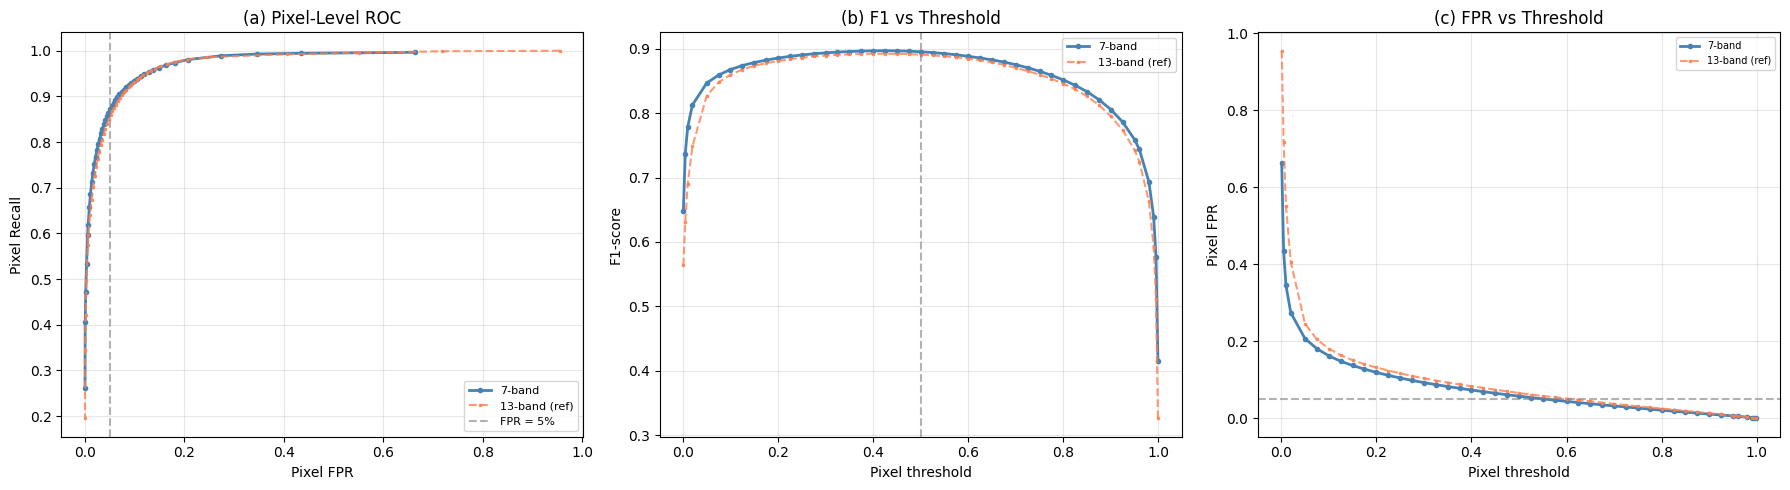

In [23]:
# =====================================================================
# Plot: Pixel level ROC curves (validation set) 7-band vs 13-band
# =====================================================================
import matplotlib.cm as cm

colors = cm.viridis(np.linspace(0.1, 0.9, len(ALL_TAGS)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sw7 = val_pix_sweep["A"]

# (a) ROC curve
ax = axes[0]
ax.plot([r["FPR"] for r in sw7], [r["Recall"] for r in sw7],
        "o-", color="steelblue", label="7-band", markersize=3, lw=2)
if HAS_13B:
    ax.plot([r["FPR"] for r in ref_val_pix], [r["Recall"] for r in ref_val_pix],
            "s--", color="coral", label="13-band (ref)", markersize=2, lw=1.5, alpha=0.8)

ax.axvline(0.05, ls="--", color="gray", alpha=0.6, label="FPR = 5%")
ax.set_xlabel("Pixel FPR")
ax.set_ylabel("Pixel Recall")
ax.set_title("(a) Pixel-Level ROC")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (b) F1 vs threshold
ax = axes[1]
ax.plot([r["t_pix"] for r in sw7], [r["F1"] for r in sw7],
        "o-", color="steelblue", label="7-band", markersize=3, lw=2)
if HAS_13B:
    ax.plot([r["t_pix"] for r in ref_val_pix], [r["F1"] for r in ref_val_pix],
            "s--", color="coral", label="13-band (ref)", markersize=2, lw=1.5, alpha=0.8)
ax.axvline(0.5, ls="--", color="gray", alpha=0.6)

ax.set_xlabel("Pixel threshold")
ax.set_ylabel("F1-score")
ax.set_title("(b) F1 vs Threshold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (c) FPR vs threshold
ax = axes[2]
ax.plot([r["t_pix"] for r in sw7], [r["FPR"] for r in sw7],
        "o-", color="steelblue", label="7-band", markersize=3, lw=2)
if HAS_13B:
    ax.plot([r["t_pix"] for r in ref_val_pix], [r["FPR"] for r in ref_val_pix],
            "s--", color="coral", label="13-band (ref)", markersize=2, lw=1.5, alpha=0.8)
ax.axhline(0.05, ls="--", color="gray", alpha=0.6)
ax.set_xlabel("Pixel threshold")
ax.set_ylabel("Pixel FPR")
ax.set_title("(c) FPR vs Threshold")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(RUN_DIR / "pixel_roc_val.png"), dpi=150, bbox_inches="tight")
plt.show()


# 10. Tile Level Threshold Sweep (Validation Set)

Tile-level `t_img = 0.70` is fixed. Sweep `t_pix`.
Constraint: **Tile-FPR ≤ 5%**.

In [24]:
print(f"Tile level at t_pix=0.50 (validation set):\n")
print(f"{'Tag':<6} | {'Name':<20} | {'Tile FPR':>9} | {'DL Eff':>9}")
print("-" * 55)
for tag in ALL_TAGS:
    sw = val_tile_sweep[tag]
    r = min(sw, key=lambda r: abs(r["t_pix"] - 0.5))
    name = EXPERIMENT_REGISTRY[tag][1]
    print(f"{tag:<6} | {name:<20} | {r['FPR']:9.4f} | {r['Downlink_Eff']:9.4f}")


Tile level at t_pix=0.50 (validation set):

Tag    | Name                 |  Tile FPR |    DL Eff
-------------------------------------------------------
A      | A (Symmetric, 7 band) |    0.0317 |    0.8644


# 11. Optimal Operational Point Selection  Strategies C

Select the pixel threshold that maximises Downlink Efficiency while keeping Tile-FPR ≤ 5% on the validation set.

- **Strategy C** = model A (symmetric BCE) + optimised threshold.

In [25]:
# =====================================================================
# Select best operational point under FPR constraint (validation)
# =====================================================================
FPR_MARGIN = 0.01  # 1% safety margin for val

def select_best_op_point(sweep_records):
    """Among thresholds where tile FPR <= (5% - margin), pick the one with
    the highest Downlink Efficiency (Recall)."""
    limit = FPR_LIMIT - FPR_MARGIN
    feasible = [r for r in sweep_records if r["FPR"] <= limit]
    if not feasible:
        print(f"  WARNING: no threshold satisfies FPR <= {limit:.1%}")
        return None
    return max(feasible, key=lambda r: r["Downlink_Eff"])


# find optimal operational point for every model
optimal_ops = {}
print(f"Optimal operational points (validation, Tile-FPR <= {FPR_LIMIT - FPR_MARGIN:.0%}):")
print(f"{'Tag':<6} | {'t_pix':>6} | {'Val FPR':>8} | {'Val DE':>8}")
print("-" * 40)
for tag in ALL_TAGS:
    opt = select_best_op_point(val_tile_sweep[tag])
    optimal_ops[tag] = opt
    if opt:
        print(f"{tag:<6} | {opt['t_pix']:6.3f} | {opt['FPR']:8.4f} | {opt['Downlink_Eff']:8.4f}")
    else:
        print(f"{tag:<6} | no feasible point ")

# build all_configs for final evaluation
# each entry: (display_label, model_tag, t_pix)
all_configs = []
for tag in ALL_TAGS:
    name = EXPERIMENT_REGISTRY[tag][1]
    # default operational point (t=0.5)
    all_configs.append((f"{name}", tag, 0.50))

# add optimised operational points
for tag in ALL_TAGS:
    opt = optimal_ops[tag]
    if opt:
        if tag == "A":
            label = f"C (A + opt. op.)"
        else:
            label = f"D_{tag.split('_')[1]} ({tag} + opt. op.)"
        all_configs.append((label, tag, opt["t_pix"]))

print(f"\n{len(all_configs)} configurations for final evaluation.")


Optimal operational points (validation, Tile-FPR <= 4%):
Tag    |  t_pix |  Val FPR |   Val DE
----------------------------------------
A      |  0.500 |   0.0317 |   0.8644

2 configurations for final evaluation.


# 12. Trade-Off Curve: Tile FPR vs Downlink Efficiency

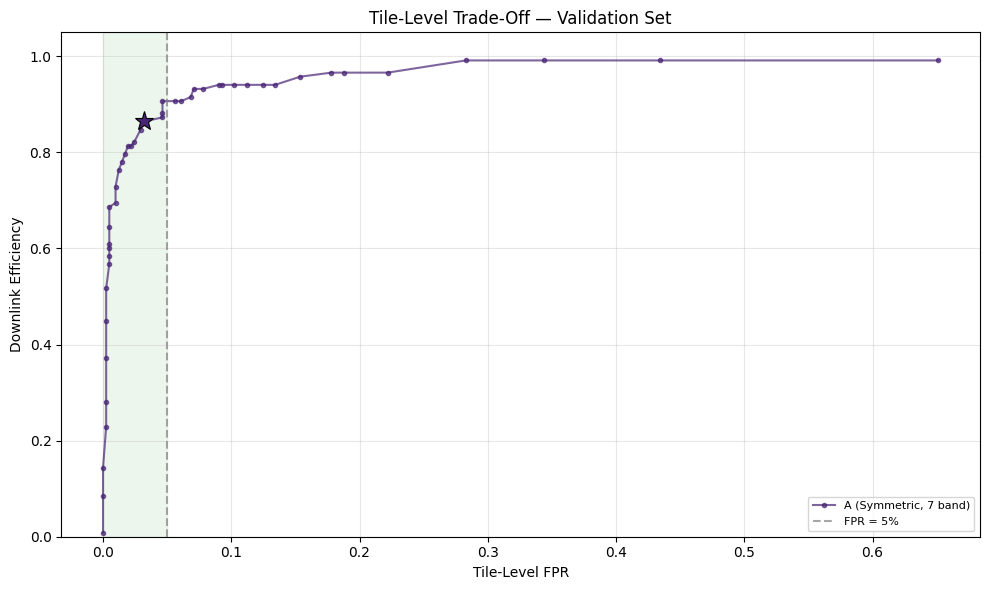

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
for tag, cl in zip(ALL_TAGS, colors):
    sw = val_tile_sweep[tag]
    name = EXPERIMENT_REGISTRY[tag][1]
    fprs = [r["FPR"] for r in sw]
    des  = [r["Downlink_Eff"] for r in sw]
    ax.plot(fprs, des, "o-", color=cl, label=name, markersize=3, alpha=0.7)

# mark optimal operational points
for tag, cl in zip(ALL_TAGS, colors):
    opt = optimal_ops[tag]
    if opt:
        ax.plot(opt["FPR"], opt["Downlink_Eff"], "*", color=cl,
                markersize=14, markeredgecolor="black", markeredgewidth=0.8)

ax.axvline(FPR_LIMIT, ls="--", color="gray", alpha=0.7, label=f"FPR = {FPR_LIMIT:.0%}")
ax.fill_betweenx([0, 1.05], 0, FPR_LIMIT, alpha=0.07, color="green")
ax.set_xlabel("Tile-Level FPR")
ax.set_ylabel("Downlink Efficiency")
ax.set_title("Tile-Level Trade-Off — Validation Set")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(RUN_DIR / "tile_tradeoff_val.png"), dpi=150, bbox_inches="tight")
plt.show()


# 12b. Joint Operational Point Sweep: t_pix × t_img
Pixel-level false positives may inflate predicted cloud fractions, making an image-level threshold of `t_img = 0.70` not necessarily optimal for segmentation-based pipelines. The ground-truth tile label is kept fixed using a mission-defined threshold of 0.70, while the thresholds applied to the predictions are jointly optimised. A sweep over `t_pix` and `t_img` is therefore performed on the validation set to identify the optimal operating point that maximises Downlink Efficiency under a Tile-FPR constraint.

In [27]:
# =====================================================================
# Joint t_pix x t_img sweep on validation set
# =====================================================================

T_PIX_RANGE = np.arange(0.30, 0.75, 0.025)
T_IMG_RANGE = np.arange(0.50, 0.95, 0.025)

GT_T_IMG = 0.70  # fixed mission design parameter

def joint_tile_sweep(model, ds, t_pix_range, t_img_range):
    """Sweep t_pix × t_img grid in a single inference pass.

      Returns list of dicts with FPR and Downlink_Eff for each pair
    """
    n_pix = len(t_pix_range)
    pred_cfs_per_tpix = [[] for k in range(n_pix)]
    gt_cfs = []

    for xb, yb in ds:
        prob = model(xb, training=False).numpy()
        yb = yb.numpy()
        for i in range(prob.shape[0]):
            p = prob[i, :, :, 0]
            y = yb[i, :, :, 0]
            valid = (y != IGNORE_LABEL)
            y_v = y[valid]
            p_v = p[valid]
            gt_cfs.append(y_v.mean())
            for j, t_pix in enumerate(t_pix_range):
                pred_cfs_per_tpix[j].append((p_v >= t_pix).mean())

    gt_cfs = np.array(gt_cfs)
    results = []
    for j, t_pix in enumerate(t_pix_range):
        pred_cfs = np.array(pred_cfs_per_tpix[j])
        for t_img in t_img_range:
            gt_tile   = (gt_cfs >= GT_T_IMG).astype(int)
            pred_tile = (pred_cfs >= t_img).astype(int)
            TP = int(np.sum((gt_tile == 1) & (pred_tile == 1)))
            FP = int(np.sum((gt_tile == 0) & (pred_tile == 1)))
            TN = int(np.sum((gt_tile == 0) & (pred_tile == 0)))
            FN = int(np.sum((gt_tile == 1) & (pred_tile == 0)))
            eps = 1e-8
            results.append({
                "t_pix": t_pix, "t_img": t_img,
                "FPR": FP / (FP + TN + eps),
                "Downlink_Eff": TP / (TP + FN + eps),
                "TP": TP, "FP": FP, "TN": TN, "FN": FN,
            })
    return results


# run for model A on validation set
print("Joint t_pix x t_img sweep for model A on VALIDATION set...")
mdl_A = load_model("A")
joint_results_A = joint_tile_sweep(mdl_A, val_ds, T_PIX_RANGE, T_IMG_RANGE)
release_model(mdl_A)

# best operational point under constraint
feasible = [r for r in joint_results_A if r["FPR"] <= FPR_LIMIT]
if feasible:
    best_joint = max(feasible, key=lambda r: r["Downlink_Eff"])
    print(f"\nBest operational point (Tile-FPR <= {FPR_LIMIT:.0%}):")
    print(f"  t_pix = {best_joint['t_pix']:.3f}")
    print(f"  t_img = {best_joint['t_img']:.3f}")
    print(f"  Tile FPR = {best_joint['FPR']:.4f}")
    print(f"  Downlink Efficiency = {best_joint['Downlink_Eff']:.4f}")
else:
    print("WARNING: no feasible point found!")
    best_joint = None

# compare with CloudScout default (t_pix=0.60, t_img=0.70)
ref = min(joint_results_A,
          key=lambda r: abs(r['t_pix'] - 0.60) + abs(r['t_img'] - 0.70))
print(f"\nCloudScout default (t_pix=0.60, t_img=0.70):")
print(f"  Tile FPR = {ref['FPR']:.4f}, DL Eff = {ref['Downlink_Eff']:.4f}")
if best_joint:
    print(f"\nImprovement: DL Eff {best_joint['Downlink_Eff'] - ref['Downlink_Eff']:+.4f}, "
          f"Tile FPR {best_joint['FPR'] - ref['FPR']:+.4f}")


Joint t_pix x t_img sweep for model A on VALIDATION set...

Best operational point (Tile-FPR <= 5%):
  t_pix = 0.425
  t_img = 0.700
  Tile FPR = 0.0463
  Downlink Efficiency = 0.9068

CloudScout default (t_pix=0.60, t_img=0.70):
  Tile FPR = 0.0195, DL Eff = 0.8136

Improvement: DL Eff +0.0932, Tile FPR +0.0268


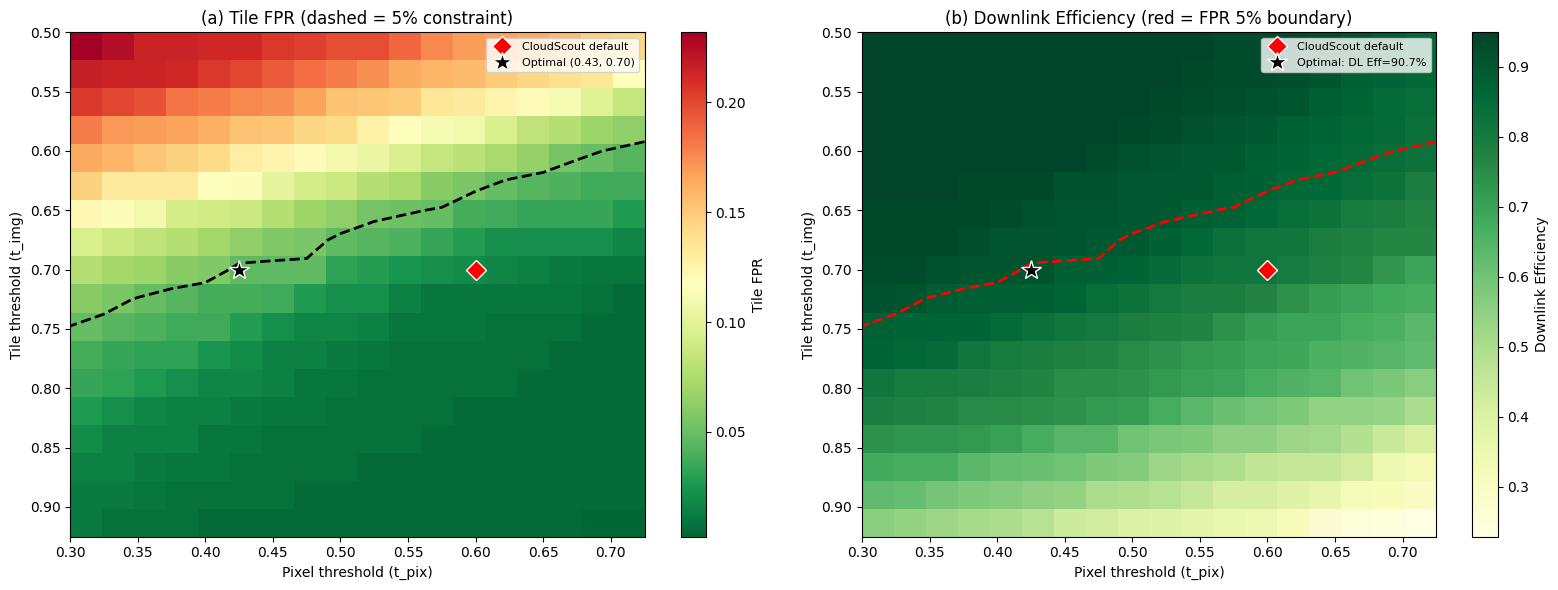

In [28]:
# =====================================================================
# Heatmap: Tile FPR and Downlink Efficiency as f(t_pix, t_img)
# =====================================================================

n_pix = len(T_PIX_RANGE)
n_img = len(T_IMG_RANGE)
fpr_grid = np.zeros((n_img, n_pix))
de_grid  = np.zeros((n_img, n_pix))

for r in joint_results_A:
    j = np.argmin(np.abs(T_PIX_RANGE - r['t_pix']))
    i = np.argmin(np.abs(T_IMG_RANGE - r['t_img']))
    fpr_grid[i, j] = r['FPR']
    de_grid[i, j]  = r['Downlink_Eff']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Tile FPR
ax = axes[0]
im = ax.imshow(fpr_grid, cmap='RdYlGn_r', aspect='auto',
               extent=[T_PIX_RANGE[0], T_PIX_RANGE[-1],
                       T_IMG_RANGE[-1], T_IMG_RANGE[0]])
ax.contour(T_PIX_RANGE, T_IMG_RANGE, fpr_grid,
           levels=[FPR_LIMIT], colors='black', linewidths=2, linestyles='--')
ax.plot(0.60, 0.70, 'D', color='red', markersize=10,
        markeredgecolor='white', markeredgewidth=1, label='CloudScout default')
if best_joint:
    ax.plot(best_joint['t_pix'], best_joint['t_img'], '*', color='black',
            markersize=15, markeredgecolor='white', markeredgewidth=1,
            label=f"Optimal ({best_joint['t_pix']:.2f}, {best_joint['t_img']:.2f})")
ax.set_xlabel('Pixel threshold (t_pix)')
ax.set_ylabel('Tile threshold (t_img)')
ax.set_title('(a) Tile FPR (dashed = 5% constraint)')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax, label='Tile FPR')

# (b) Downlink Efficiency
ax = axes[1]
im = ax.imshow(de_grid, cmap='YlGn', aspect='auto',
               extent=[T_PIX_RANGE[0], T_PIX_RANGE[-1],
                       T_IMG_RANGE[-1], T_IMG_RANGE[0]])
ax.contour(T_PIX_RANGE, T_IMG_RANGE, fpr_grid,
           levels=[FPR_LIMIT], colors='red', linewidths=2, linestyles='--')
ax.plot(0.60, 0.70, 'D', color='red', markersize=10,
        markeredgecolor='white', markeredgewidth=1, label='CloudScout default')
if best_joint:
    ax.plot(best_joint['t_pix'], best_joint['t_img'], '*', color='black',
            markersize=15, markeredgecolor='white', markeredgewidth=1,
            label=f"Optimal: DL Eff={best_joint['Downlink_Eff']:.1%}")
ax.set_xlabel('Pixel threshold (t_pix)')
ax.set_ylabel('Tile threshold (t_img)')
ax.set_title('(b) Downlink Efficiency (red = FPR 5% boundary)')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax, label='Downlink Efficiency')

plt.tight_layout()
plt.savefig(str(RUN_DIR / 'joint_tpix_timg_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# 13. Final Evaluation on Test Set — All Configurations

In [29]:
# =====================================================================
# Combined pixel + tile evaluation on TEST set
# =====================================================================

print("Combined Performance Summary on TEST set\n")
print(f"{'Config':<28} | {'t_pix':>5} | {'Pix FPR':>8} | {'Pix F1':>7} | "
      f"{'Tile FPR':>9} | {'DL Eff':>7}")
print("-" * 90)

for label, tag, thr in all_configs:
    px = min(test_pix_sweep[tag], key=lambda r: abs(r["t_pix"] - thr))
    tl = min(test_tile_sweep[tag], key=lambda r: abs(r["t_pix"] - thr))
    print(f"{label:<28} | {thr:5.2f} | {px['FPR']:8.4f} | {px['F1']:7.4f} | "
          f"{tl['FPR']:9.4f} | {tl['Downlink_Eff']:7.4f}")

# highlight best under constraint
print(f"\nOperational constraint: Tile FPR <= {FPR_LIMIT:.0%}")
feasible = []
for label, tag, thr in all_configs:
    tl = min(test_tile_sweep[tag], key=lambda r: abs(r["t_pix"] - thr))
    px = min(test_pix_sweep[tag], key=lambda r: abs(r["t_pix"] - thr))
    if tl["FPR"] <= FPR_LIMIT:
        feasible.append((label, thr, tl["Downlink_Eff"], tl["FPR"], px["F1"]))

if feasible:
    best = max(feasible, key=lambda x: x[2])

    print(f"Best: {best[0]} (t_pix={best[1]:.2f}, Tile FPR={best[3]:.4f}, DL Eff={best[2]:.4f}, F1={best[4]:.4f})")


Combined Performance Summary on TEST set

Config                       | t_pix |  Pix FPR |  Pix F1 |  Tile FPR |  DL Eff
------------------------------------------------------------------------------------------
A (Symmetric, 7 band)        |  0.50 |   0.0528 |  0.8938 |    0.0422 |  0.8607
C (A + opt. op.)             |  0.50 |   0.0528 |  0.8938 |    0.0422 |  0.8607

Operational constraint: Tile FPR <= 5%
Best: A (Symmetric, 7 band) (t_pix=0.50, Tile FPR=0.0422, DL Eff=0.8607, F1=0.8938)


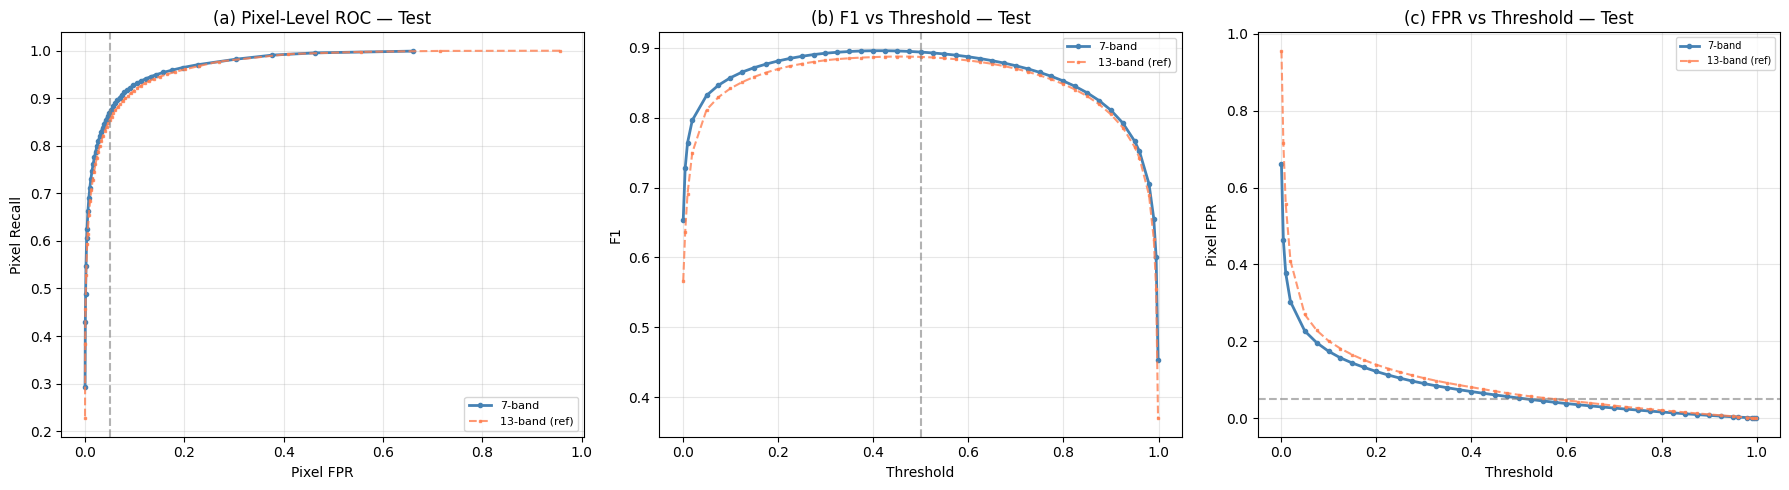

In [30]:
# =====================================================================
# Plot: Pixel ROC curves on TEST set - 7-band vs 13-band
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sw7 = test_pix_sweep["A"]

ax = axes[0]
ax.plot([r["FPR"] for r in sw7], [r["Recall"] for r in sw7],
        "o-", color="steelblue", label="7-band", markersize=3, lw=2)
if HAS_13B:
    ax.plot([r["FPR"] for r in ref_test_pix], [r["Recall"] for r in ref_test_pix],
            "s--", color="coral", label="13-band (ref)", markersize=2, lw=1.5, alpha=0.8)

ax.axvline(0.05, ls="--", color="gray", alpha=0.6)
ax.set_xlabel("Pixel FPR"); ax.set_ylabel("Pixel Recall")
ax.set_title("(a) Pixel-Level ROC — Test")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot([r["t_pix"] for r in sw7], [r["F1"] for r in sw7],
        "o-", color="steelblue", label="7-band", markersize=3, lw=2)
if HAS_13B:
    ax.plot([r["t_pix"] for r in ref_test_pix], [r["F1"] for r in ref_test_pix],
            "s--", color="coral", label="13-band (ref)", markersize=2, lw=1.5, alpha=0.8)

ax.axvline(0.5, ls="--", color="gray", alpha=0.6)
ax.set_xlabel("Threshold"); ax.set_ylabel("F1")
ax.set_title("(b) F1 vs Threshold — Test")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot([r["t_pix"] for r in sw7], [r["FPR"] for r in sw7],
        "o-", color="steelblue", label="7-band", markersize=3, lw=2)
if HAS_13B:
    ax.plot([r["t_pix"] for r in ref_test_pix], [r["FPR"] for r in ref_test_pix],
            "s--", color="coral", label="13-band (ref)", markersize=2, lw=1.5, alpha=0.8)

ax.axhline(0.05, ls="--", color="gray", alpha=0.6)
ax.set_xlabel("Threshold"); ax.set_ylabel("Pixel FPR")
ax.set_title("(c) FPR vs Threshold — Test")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(RUN_DIR / "pixel_roc_test.png"), dpi=150, bbox_inches="tight")
plt.show()
